# Neural Network Based Speech Recognition Using MFCC Features
### Based on: *Barua et al., ICIEV 2014*
### Dataset: Google Speech Commands v0.02

---

##  Project Overview

This notebook implements a **two-stage, speaker-gated speech recognition system** based on the architecture described in Barua et al. (ICIEV 2014). The system is trained on the **Google Speech Commands v0.02** dataset and uses **Mel-Frequency Cepstral Coefficients (MFCCs)** as the core feature representation for all audio.

- **Stage 1 — Speaker Recognition (Network 1):** A binary MLP classifier that acts as a security gatekeeper. Given an audio sample, it decides whether the speaker is the pre-registered *authorized* user or an *unauthorized* speaker.

- **Stage 2 — Command Recognition (Network 2):** A 7-class MLP classifier that identifies which of 6 core commands was spoken (`on`, `off`, `stop`, `go`, `up`, `down`), or rejects the audio as `unknown` if it does not match any of the target commands.

### Full Pipeline
```
Audio Files → MFCC Extraction → Data Preparation → Train Network 1 (Speaker Gate) → Train Network 2 (Command Classifier) → Inference → Results
```

### Member Responsibilities
| Member | Role |
|--------|------|
| Member 1 | Data Filtering — dataset audit, speaker selection, label creation, data assembly |
| Member 2 | MFCC Extraction — feature extraction function, extraction loop, visualization |
| Member 3 | Dataset Builder — feature aggregation, train/test split |
| Member 4 | Network 1 — speaker model training, evaluation, loss curves, confusion matrix |
| Member 5 | Network 2 — command model training, evaluation, loss curves, confusion matrix |
| Member 6 | Integration — `recognize()` pipeline, end-to-end test, final summary |


In [38]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import os
import random
from collections import defaultdict, Counter
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tqdm import tqdm

In [39]:
import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download("yashdogra/speech-commands")

print("Dataset path:", path)


Using Colab cache for faster access to the 'speech-commands' dataset.
Dataset path: /kaggle/input/speech-commands


In [40]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## Member 1 — Data Filtering

This section handles all data preparation before any model is trained. The steps are:

1. **Dataset Audit:** Count audio files per command class to check for imbalance or corrupted folders.
2. **Command Filtering:** Select 6 phonetically distinct, naturally balanced command words.
3. **Speaker Selection:** Identify and isolate a single authorized speaker from the dataset; undersample unauthorized speakers to achieve a 1-to-1 balance for Network 1.
4. **Unknown Class Construction:** Sample a set of audio files from non-command folders to serve as a "catch-all" rejection class for Network 2.
5. **Label Encoding:** Map string labels to integer indices required by the neural network.
6. **Data Assembly:** Build the final file path lists and integer label arrays for both networks, plus a deduplicated union for MFCC extraction.


### 1.Dataset Audit


In [41]:
commands = {d.name: len(list(d.glob('*.wav'))) for d in Path(path).iterdir() if d.is_dir() and d.name != "_background_noise_"}

print(f"Total Commands: {len(commands)}\n\n{'Command Name':<20} | File Count\n" + "-" * 40)
for cmd, count in sorted(commands.items()):
    print(f"{cmd:<20} | {count}")

Total Commands: 35

Command Name         | File Count
----------------------------------------
backward             | 1664
bed                  | 2014
bird                 | 2064
cat                  | 2031
dog                  | 2128
down                 | 3917
eight                | 3787
five                 | 4052
follow               | 1579
forward              | 1557
four                 | 3728
go                   | 3880
happy                | 2054
house                | 2113
learn                | 1575
left                 | 3801
marvin               | 2100
nine                 | 3934
no                   | 3941
off                  | 3745
on                   | 3845
one                  | 3890
right                | 3778
seven                | 3998
sheila               | 2022
six                  | 3860
stop                 | 3872
three                | 3727
tree                 | 1759
two                  | 3880
up                   | 3723
visual               | 1592
wow      

### 2.Command Filtering

In [42]:
random.seed(42)

basic_controls = ['on', 'off', 'stop', 'go', 'up', 'down']
selected = {k: v for k, v in commands.items() if k in basic_controls}
for cmd, count in selected.items():
    print(f"{cmd:<10} | {count} files")

N_per_cmd = 600


off        | 3745 files
go         | 3880 files
on         | 3845 files
down       | 3917 files
stop       | 3872 files
up         | 3723 files


### 3. Speaker Selection

In [43]:
spk_files_basic = defaultdict(list)
for cmd in basic_controls:
    for f in Path(path).joinpath(cmd).glob('*.wav'):
        spk_files_basic[f.name.split('_')[0]].append(f)

balanced = {s: fs for s, fs in spk_files_basic.items() if len({f.parent.name for f in fs}) == len(basic_controls)}
auth_speaker, _ = max(balanced.items(), key=lambda x: len(x[1]))

auth_files = list(Path(path).glob(f'*/*{auth_speaker}*.wav'))
auth_files = [f for f in auth_files if f.parent.name != "_background_noise_"]

all_unauth_files = [f for f in Path(path).glob('*/*.wav') if f.name.split('_')[0] != auth_speaker and f.parent.name != "_background_noise_"]
unauth_files = random.sample(all_unauth_files, len(auth_files))

print(f"Authorized Speaker ID: {auth_speaker} ({len(auth_files)} files across all words)")

Authorized Speaker ID: 893705bb (263 files across all words)


#### Save test set (auth, unauth)

In [44]:
from google.colab import drive
from collections import defaultdict
from pathlib import Path
import shutil, json


drive.mount('/content/drive')

DRIVE_TEST_DIR = Path('/content/drive/MyDrive/speech_test_files')
MANIFEST_FILE  = DRIVE_TEST_DIR / 'manifest.json'
DRIVE_TEST_DIR.mkdir(parents=True, exist_ok=True)

# Load manifest if it exists
if MANIFEST_FILE.exists():
    with open(MANIFEST_FILE) as fh:
        manifest = json.load(fh)
    print('Manifest found — reusing existing test split (no random sampling will occur).')
else:
    manifest = {}
    print('No manifest found — creating fresh test split.')


def _abs_paths(key):
    """Reconstruct absolute paths from manifest relative paths."""
    return set(str(Path(path) / rel) for rel in manifest[key])



# AUTHORIZED TEST SET
auth_dir = DRIVE_TEST_DIR / 'authorized'

if 'authorized' in manifest:
    auth_test_paths = _abs_paths('authorized')

else:
    auth_by_cmd = defaultdict(list)
    for f in auth_files:
        cmd = Path(str(f)).parent.name
        if cmd != "_background_noise_":
            auth_by_cmd[cmd].append(str(f))

    reserved = []
    for cmd in sorted(auth_by_cmd):
        candidates = sorted(auth_by_cmd[cmd])
        reserved.append(random.choice(candidates))

    auth_test_paths = set(reserved)

    auth_dir.mkdir(parents=True, exist_ok=True)

    for fp in reserved:
        fp = Path(fp)
        dest_dir = auth_dir / fp.parent.name
        dest_dir.mkdir(parents=True, exist_ok=True)

        dest = dest_dir / fp.name
        if not dest.exists():
            shutil.copy(fp, dest)

    manifest['authorized'] = [
        str(Path(fp).relative_to(path)) for fp in reserved
    ]
auth_files = [f for f in auth_files if str(f) not in auth_test_paths]
print(f'Authorized   — reserved: {len(auth_test_paths)},  training pool: {len(auth_files)}')


# UNAUTHORIZED TEST SET
unauth_dir = DRIVE_TEST_DIR / 'unauthorized'

if 'unauthorized' in manifest:
    unauth_test_paths = _abs_paths('unauthorized')

else:
    unauth_by_cmd = defaultdict(list)
    for f in unauth_files:
        cmd = Path(str(f)).parent.name
        if cmd != "_background_noise_":
            unauth_by_cmd[cmd].append(str(f))

    reserved = []
    for cmd in sorted(unauth_by_cmd):
        candidates = sorted(unauth_by_cmd[cmd])
        reserved.append(random.choice(candidates))

    unauth_test_paths = set(reserved)

    unauth_dir.mkdir(parents=True, exist_ok=True)
    for fp in reserved:
        dest = unauth_dir / Path(fp).name
        if not dest.exists():
            shutil.copy(fp, str(dest))

    manifest['unauthorized'] = [
        str(Path(fp).relative_to(path)) for fp in reserved
    ]

unauth_files = [f for f in unauth_files if str(f) not in unauth_test_paths]
print(f'Unauthorized — reserved: {len(unauth_test_paths)},  training pool: {len(unauth_files)}')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Manifest found — reusing existing test split (no random sampling will occur).
Authorized   — reserved: 32,  training pool: 231
Unauthorized — reserved: 35,  training pool: 263


### 4. Unknown Class Construction

In [45]:
all_other_files = [f for f in Path(path).glob('*/*.wav')
                   if f.parent.name not in basic_controls
                   and f.name.split('_')[0] != auth_speaker]

unknown_noise_sample = random.sample(all_other_files, N_per_cmd)
print(f"Unknown pool size: {len(all_other_files)} files available")
print(f"Preview sample (not used in training): {len(unknown_noise_sample)} files")


Unknown pool size: 82668 files available
Preview sample (not used in training): 600 files


#### Save test set (unknown)

In [46]:
N_INTEGRATION_TEST = 6
unknown_dir = DRIVE_TEST_DIR / 'unknown'

if 'unknown' in manifest:
    unknown_test_paths = _abs_paths('unknown')

else:
    # Group by non-command folder, pick 1 file per folder for diversity
    unknown_by_folder = defaultdict(list)
    for f in all_other_files:
        folder = Path(str(f)).parent.name
        unknown_by_folder[folder].append(str(f))

    sample_folders = random.sample(
        sorted(unknown_by_folder.keys()),
        min(N_INTEGRATION_TEST, len(unknown_by_folder))
    )

    reserved = [
        random.choice(sorted(unknown_by_folder[folder]))
        for folder in sample_folders
    ]

    unknown_test_paths = set(reserved)

    unknown_dir.mkdir(parents=True, exist_ok=True)
    for fp in reserved:
        dest = unknown_dir / Path(fp).name
        if not dest.exists():
            shutil.copy(fp, str(dest))

    manifest['unknown'] = [
        str(Path(fp).relative_to(path)) for fp in reserved
    ]

# Exact path removal
all_other_files = [f for f in all_other_files if str(f) not in unknown_test_paths]

with open(MANIFEST_FILE, 'w') as fh:
    json.dump(manifest, fh, indent=2)

### 5. Label Encoding

In [47]:
command_labels = {cmd: idx for idx, cmd in enumerate(list(basic_controls) + ['unknown'])}
speaker_labels = {'authorized': 1, 'unauthorized': 0}

### 6. Data Assembly


**Note :Balancing the unknown class:**
The unknown class (audio from non-command folders) is sampled to match the per-command file count (~3800), so that all 7 classes have approximately equal representation in the training data. This prevents the model from learning to over-predict `unknown` due to a class-size advantage.


In [48]:
#net 1:  We use auth_files + unauth_files (no unknown needed,binary task)
X_spk = [str(f) for f in auth_files + unauth_files]
y_speaker = [1] * len(auth_files) + [0] * len(unauth_files)

#net 2 :

cmd_files_all = []
cmd_labels_all = []

for cmd in basic_controls:
    cmd_wavs = list(Path(path).joinpath(cmd).glob('*.wav'))
    all_cmd_wavs = cmd_wavs
    cmd_idx = command_labels[cmd]
    cmd_files_all.extend([str(f) for f in all_cmd_wavs])
    cmd_labels_all.extend([cmd_idx] * len(all_cmd_wavs))

unknown_label = command_labels['unknown']

unknown_train_files = random.sample(all_other_files, 3800)
cmd_files_all.extend([str(f) for f in unknown_train_files])
cmd_labels_all.extend([unknown_label] * len(unknown_train_files))
# Add unknown class

X_cmd = cmd_files_all
y_command = cmd_labels_all

#keep unified X for MFCC extraction (union of both)
all_files_set = list(dict.fromkeys(X_spk + X_cmd))
file_to_idx = {f: i for i, f in enumerate(all_files_set)}

#Sanity checks
assert len(X_spk) == len(y_speaker), "Speaker data mismatch"
assert len(X_cmd) == len(y_command), "Command data mismatch"

print(f"Speaker Network  — total files : {len(X_spk)} (auth={len(auth_files)}, unauth={len(unauth_files)})")
print(f"Command Network  — total files : {len(X_cmd)}")
print(f"  Per-class counts: { {k: cmd_labels_all.count(v) for k, v in command_labels.items()} }")
print(f"Unique files to extract MFCC from: {len(all_files_set)}")

Speaker Network  — total files : 494 (auth=231, unauth=263)
Command Network  — total files : 26782
  Per-class counts: {'on': 3845, 'off': 3745, 'stop': 3872, 'go': 3880, 'up': 3723, 'down': 3917, 'unknown': 3800}
Unique files to extract MFCC from: 27131


## Member 2 — MFCC Extraction

This section extracts Mel-Frequency Cepstral Coefficient (MFCC) features from every unique audio file in the dataset. The extracted features are stored in a dictionary (`mfcc_cache`) keyed by file path, so each file is processed only once even if it appears in both networks' datasets.

MFCC is the standard feature representation for speech processing tasks. It converts a raw audio waveform into a compact 2D matrix where:
- **Rows** represent different frequency bands (modeled after human auditory perception).
- **Columns** represent short time windows (frames), capturing how the spectrum evolves over time.



### MFCC Extraction Function
The final output shape per audio file is `(48, ~100)`:
- Rows 0..15: base MFCC
- Rows 16..31: delta MFCC (velocity : how fast the spectrum changes)
- Rows 32..47: delta-delta MFCC (acceleration: how fast the change itself changes)


In [49]:
def extract_mfcc(filepath, sr=16000, n_mfcc=16, n_fft=512, hop_length=160, win_length=400):

    y, _ = librosa.load(str(filepath), sr=sr)

    target_length = sr
    if len(y) < target_length:
        y = np.pad(y, (0, target_length - len(y)))
    else:
        y = y[:target_length]

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=win_length,
        window='hann'
    )
    delta_mfcc  = librosa.feature.delta(mfcc)          #rate of change
    delta2_mfcc = librosa.feature.delta(mfcc, order=2) #acceleration

    # Stack vertically shape: (n_mfcc * 3, time_frames) = (48, ~100)
    combined = np.vstack([mfcc, delta_mfcc, delta2_mfcc])

    return combined



### Extraction Loop

All unique audio files (the deduplicated union of Network 1 and Network 2 file lists) are processed sequentially. Each file's MFCC matrix is stored in `mfcc_cache` by its file path string. Files that fail to load (e.g., corrupted audio) are tracked in `failed` and skipped.


In [50]:
mfcc_cache = {}
failed = []

print(f'Extracting MFCC features from {len(all_files_set)} unique audio files...')
for file_path in tqdm(all_files_set):
    try:
        mfcc = extract_mfcc(file_path)
        mfcc_cache[file_path] = mfcc
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        failed.append(file_path)

print(f"\nMFCC extraction completed.")
print(f"  Successfully extracted : {len(mfcc_cache)} files")
print(f"  Failed / skipped       : {len(failed)} files")
if mfcc_cache:
    sample_shape = next(iter(mfcc_cache.values())).shape
    print(f"  Each MFCC shape        : {sample_shape}  (n_mfcc × time_frames)")

Extracting MFCC features from 27131 unique audio files...


100%|██████████| 27131/27131 [04:59<00:00, 90.65it/s] 


MFCC extraction completed.
  Successfully extracted : 27131 files
  Failed / skipped       : 0 files
  Each MFCC shape        : (48, 101)  (n_mfcc × time_frames)


### MFCC Extraction Results: Building Feature Matrices


In [51]:
# Network 1: Speaker Recognition
X_mfcc_spk = []
y_spk_clean = []
for fp, lbl in zip(X_spk, y_speaker):
    if fp in mfcc_cache:
        X_mfcc_spk.append(mfcc_cache[fp])
        y_spk_clean.append(lbl)
y_spk_clean = np.array(y_spk_clean, dtype=np.int32)

# Network 2: Command Recognition
X_mfcc_cmd = []
y_cmd_clean = []
for fp, lbl in zip(X_cmd, y_command):
    if fp in mfcc_cache:
        X_mfcc_cmd.append(mfcc_cache[fp])
        y_cmd_clean.append(lbl)
y_cmd_clean = np.array(y_cmd_clean, dtype=np.int32)

print(f"Network 1 samples : {len(X_mfcc_spk)}  (auth={int(y_spk_clean.sum())}, unauth={int((y_spk_clean==0).sum())})")
print(f"Network 2 samples : {len(X_mfcc_cmd)}")
print(f"  Class distribution: { dict(sorted(Counter(y_cmd_clean.tolist()).items())) }")
print(f"  MFCC feature shape: {X_mfcc_cmd[0].shape}")

Network 1 samples : 494  (auth=231, unauth=263)
Network 2 samples : 26782
  Class distribution: {0: 3845, 1: 3745, 2: 3872, 3: 3880, 4: 3723, 5: 3917, 6: 3800}
  MFCC feature shape: (48, 101)


### MFCC Feature Visualization

sanity check


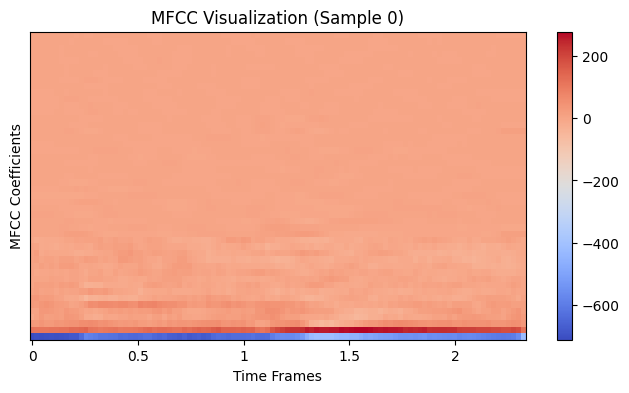

In [52]:
#one sample
idx = 0
sample_key = next(iter(mfcc_cache))
mfcc = mfcc_cache[sample_key]

plt.figure(figsize=(8, 4))

librosa.display.specshow(
    mfcc,
    x_axis='time'
)

plt.colorbar()
plt.title("MFCC Visualization (Sample 0)")
plt.xlabel("Time Frames")
plt.ylabel("MFCC Coefficients")
plt.show()

## Member 3 — Dataset Builder

This section converts the raw MFCC matrices from Member 2 into fixed-length feature vectors and performs the train/test split for both networks.

### Feature Aggregation Strategy
Both networks ultimately used the same feature extraction strategy based on flattening the MFCC representation into a fixed-length vector.


In [53]:
def mfcc_to_features_cmd(mfcc_matrix):
    return mfcc_matrix.flatten()

X_flat_spk = np.array([mfcc_to_features_cmd(mfcc) for mfcc in X_mfcc_spk])

X_flat_cmd = np.array([mfcc_to_features_cmd(mfcc) for mfcc in X_mfcc_cmd])

print(f"Network 1 — Feature matrix shape : {X_flat_spk.shape} ")
print(f"Network 2 — Feature matrix shape : {X_flat_cmd.shape} ")


Network 1 — Feature matrix shape : (494, 4848) 
Network 2 — Feature matrix shape : (26782, 4848) 


In [54]:
# Network 1: Speaker Recognition (binary: 1=authorized, 0=unauthorized)
X_train_spk, X_test_spk, y_train_spk, y_test_spk = train_test_split(
    X_flat_spk, y_spk_clean, test_size=0.2, random_state=9, stratify=y_spk_clean
)

# Network 2: Command Recognition (7 classes)
X_train_cmd, X_test_cmd, y_train_cmd, y_test_cmd = train_test_split(
    X_flat_cmd, y_cmd_clean, test_size=0.2, random_state=42, stratify=y_cmd_clean
)

label_names = list(basic_controls) + ['unknown']


print("── Speaker Network Data ──")
print(f"  Train: {X_train_spk.shape}  |  Test: {X_test_spk.shape}")

print(f"  Authorized train samples   : {(y_train_spk == 1).sum()}")
print(f"  Unauthorized train samples : {(y_train_spk == 0).sum()}")

print(f"  Authorized test samples    : {(y_test_spk == 1).sum()}")
print(f"  Unauthorized test samples  : {(y_test_spk == 0).sum()}")

print("\n── Command Network Data ──")
print(f"  Train: {X_train_cmd.shape}  |  Test: {X_test_cmd.shape}")
print(f"  Class distribution (train): { dict(sorted(Counter(y_train_cmd.tolist()).items())) }")
print(f"  Class distribution (test) : { dict(sorted(Counter(y_test_cmd.tolist()).items())) }")

── Speaker Network Data ──
  Train: (395, 4848)  |  Test: (99, 4848)
  Authorized train samples   : 185
  Unauthorized train samples : 210
  Authorized test samples    : 46
  Unauthorized test samples  : 53

── Command Network Data ──
  Train: (21425, 4848)  |  Test: (5357, 4848)
  Class distribution (train): {0: 3076, 1: 2996, 2: 3098, 3: 3104, 4: 2978, 5: 3133, 6: 3040}
  Class distribution (test) : {0: 769, 1: 749, 2: 774, 3: 776, 4: 745, 5: 784, 6: 760}


### Feature Normalization

Normalization was used for Network 2 only

In [55]:
from sklearn.preprocessing import StandardScaler
import joblib

cmd_scaler = StandardScaler()

X_train_cmd = cmd_scaler.fit_transform(X_train_cmd)


X_test_cmd = cmd_scaler.transform(X_test_cmd)

In [56]:
joblib.dump(cmd_scaler, 'cmd_scaler.pkl')

['cmd_scaler.pkl']

## Member 4 — Network 1: Speaker Recognition

This section trains and evaluates the **Speaker Recognition Network** — the first stage of the two-stage pipeline. Its sole job is to act as a binary security gate: given an audio sample, decide whether it was spoken by the single *authorized* speaker (label = 1) or by anyone else (label = 0).


### Training Network 1


In [57]:
spk_model = MLPClassifier(
    hidden_layer_sizes=(512,256),
    activation='relu',
    solver='adam',
    learning_rate_init=0.0001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42,
    verbose=False
)

print("Training Speaker Recognition Network...")
spk_model.fit(X_train_spk, y_train_spk)
print(f"Training stopped after {spk_model.n_iter_} iterations (early stopping active).")


Training Speaker Recognition Network...
Training stopped after 47 iterations (early stopping active).


### Evaluation





In [58]:
y_pred_spk = spk_model.predict(X_test_spk)

train_acc = accuracy_score(y_train_spk, spk_model.predict(X_train_spk))
test_acc  = accuracy_score(y_test_spk, y_pred_spk)

print(f"Speaker Network — Train Accuracy : {train_acc * 100:.2f}%")
print(f"Speaker Network — Test  Accuracy : {test_acc  * 100:.2f}%")
print()
print("Classification Report:")
print(classification_report(y_test_spk, y_pred_spk, target_names=['Unauthorized', 'Authorized']))

Speaker Network — Train Accuracy : 99.24%
Speaker Network — Test  Accuracy : 98.99%

Classification Report:
              precision    recall  f1-score   support

Unauthorized       0.98      1.00      0.99        53
  Authorized       1.00      0.98      0.99        46

    accuracy                           0.99        99
   macro avg       0.99      0.99      0.99        99
weighted avg       0.99      0.99      0.99        99



### Loss & Validation Curves


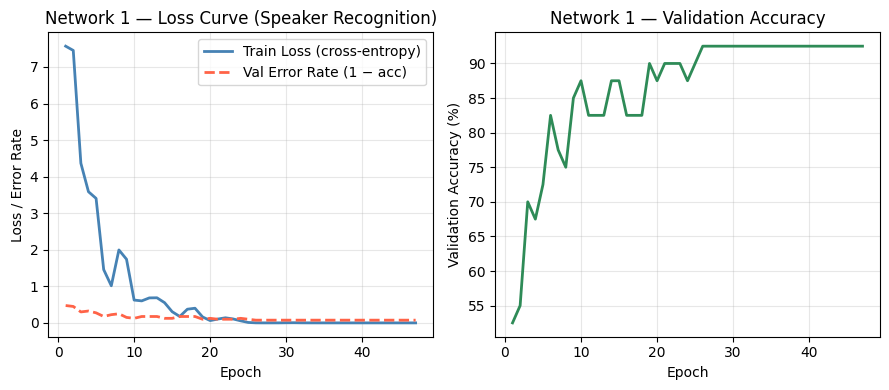

Loss curve saved.


In [59]:
import matplotlib.pyplot as plt

train_loss = spk_model.loss_curve_
val_scores  = spk_model.validation_scores_

val_error_rate = [1 - s for s in val_scores]
epochs = range(1, len(train_loss) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))

ax1.plot(epochs, train_loss, color='steelblue', linewidth=2, label='Train Loss (cross-entropy)')
ax1.plot(range(1, len(val_error_rate) + 1), val_error_rate,
         color='tomato', linewidth=2, linestyle='--', label='Val Error Rate (1 − acc)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss / Error Rate')
ax1.set_title('Network 1 — Loss Curve (Speaker Recognition)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(range(1, len(val_scores) + 1), [s * 100 for s in val_scores],
         color='seagreen', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation Accuracy (%)')
ax2.set_title('Network 1 — Validation Accuracy')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('network1_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Loss curve saved.")


### Confusion Matrix

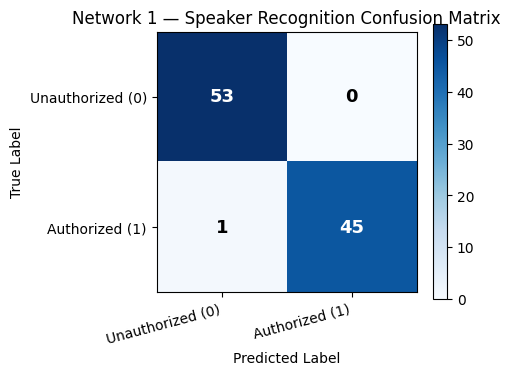

True Positives  (Auth → Auth)  : 45
True Negatives  (Unauth→Unauth): 53
False Positives (Unauth→Auth)  : 0  ← security risk
False Negatives (Auth → Unauth): 1  ← usability risk


In [60]:
cm = confusion_matrix(y_test_spk, y_pred_spk)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax)

classes = ['Unauthorized (0)', 'Authorized (1)']
tick_marks = np.arange(len(classes))
ax.set_xticks(tick_marks); ax.set_xticklabels(classes, rotation=15, ha='right')
ax.set_yticks(tick_marks); ax.set_yticklabels(classes)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black',
                fontsize=13, fontweight='bold')

ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_title('Network 1 — Speaker Recognition Confusion Matrix')
plt.tight_layout()
plt.savefig('network1_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


tn, fp, fn, tp = cm.ravel()
print(f"True Positives  (Auth → Auth)  : {tp}")
print(f"True Negatives  (Unauth→Unauth): {tn}")
print(f"False Positives (Unauth→Auth)  : {fp}  ← security risk")
print(f"False Negatives (Auth → Unauth): {fn}  ← usability risk")

## Member 5 : Network 2: Command Recognition




### Training Network 2


In [61]:
cmd_model = MLPClassifier(
    hidden_layer_sizes=(256,128),
    activation='relu',
    solver='adam',
    alpha= 0.01,
    learning_rate_init=0.0015,
    max_iter=400,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42,
    verbose=False,
)
cmd_model.fit(X_train_cmd, y_train_cmd)
print(f"Training stopped after {cmd_model.n_iter_} iterations")


Training stopped after 56 iterations


### Evaluation



In [62]:
Y_pred_cmd = cmd_model.predict(X_test_cmd)

cmd_train_acc = accuracy_score(y_train_cmd, cmd_model.predict(X_train_cmd)) *100
cmd_test_acc = accuracy_score(y_test_cmd, Y_pred_cmd) *100

print("Command Network")
print(f"Train Accuracy : {cmd_train_acc:.2f}%")
print(f"Test Accuracy : {cmd_test_acc:.2f}%")

label_names = list(basic_controls) + ['unknown']
print("\n Classification Report: ")
print(classification_report(y_test_cmd , Y_pred_cmd, target_names=label_names))

Command Network
Train Accuracy : 98.07%
Test Accuracy : 80.51%

 Classification Report: 
              precision    recall  f1-score   support

          on       0.84      0.82      0.83       769
         off       0.80      0.86      0.83       749
        stop       0.91      0.88      0.89       774
          go       0.80      0.79      0.80       776
          up       0.79      0.79      0.79       745
        down       0.81      0.80      0.81       784
     unknown       0.69      0.70      0.70       760

    accuracy                           0.81      5357
   macro avg       0.81      0.81      0.81      5357
weighted avg       0.81      0.81      0.81      5357



### Loss & Validation Accuracy Curves


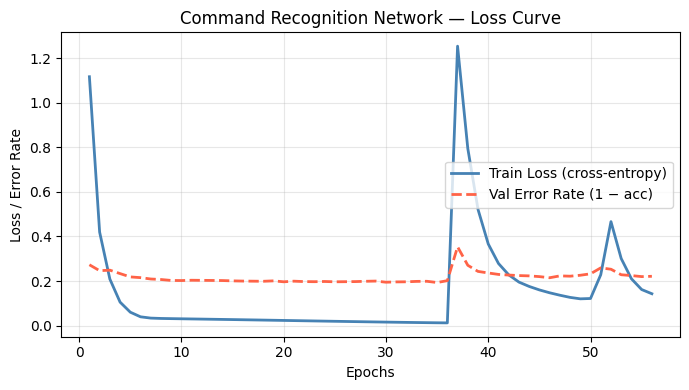

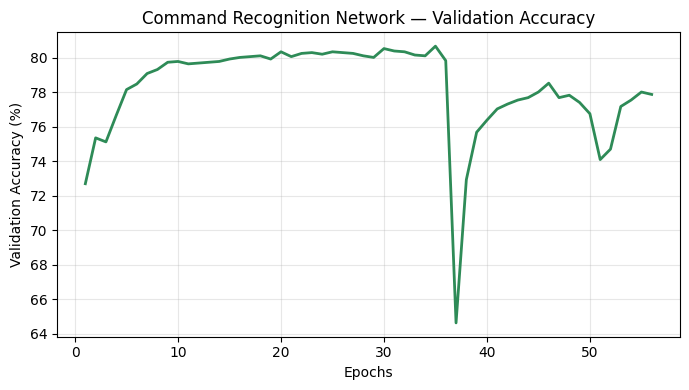

In [63]:
cmd_train_loss = cmd_model.loss_curve_
cmd_val_scores = cmd_model.validation_scores_

cmd_val_error = [1 - s for s in cmd_val_scores]
cmd_epochs = range(1, len(cmd_train_loss) + 1)

plt.figure(figsize=(7, 4))
plt.plot(cmd_epochs, cmd_train_loss, color='steelblue', linewidth=2, label='Train Loss (cross-entropy)')
plt.plot(range(1, len(cmd_val_error) + 1), cmd_val_error,
         color='tomato', linewidth=2, linestyle='--', label='Val Error Rate (1 − acc)')
plt.xlabel('Epochs')
plt.ylabel('Loss / Error Rate')
plt.title('Command Recognition Network — Loss Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cmd_val_scores) + 1), [s * 100 for s in cmd_val_scores],
         color='seagreen', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy (%)')
plt.title('Command Recognition Network — Validation Accuracy')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



### Confusion Matrix


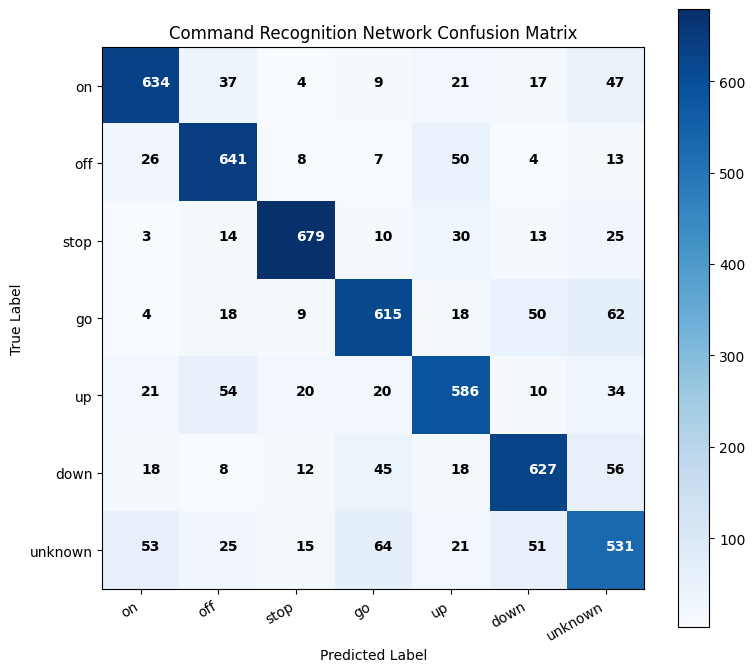

In [64]:
cmd_cm = confusion_matrix(y_test_cmd, Y_pred_cmd)

fig, ax = plt.subplots(figsize=(8,7))
im = ax.imshow(cmd_cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im , ax=ax)

tick_marks =np.arange(len(label_names))
ax.set_xticks(tick_marks)
ax.set_xticklabels(label_names, rotation=30 ,ha='right')

ax.set_yticks(tick_marks)
ax.set_yticklabels(label_names)

thresh=cmd_cm.max()/2.0
for i in range(cmd_cm.shape[0]):
  for j in range(cmd_cm.shape[1]):
    ax.text(j, i, format(cmd_cm[i , j], 'd'),
    color = 'white' if cmd_cm[i,j] > thresh else 'black',
    fontsize =10, fontweight = 'bold')



ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_title('Command Recognition Network Confusion Matrix')
plt.tight_layout()
plt.show()


## Member 6 :Integration & Results

This section assembles the full two-stage pipeline into a single `recognize()` function, runs an end-to-end qualitative test, saves the trained models to disk, and prints the final summary table and conclusion.


### Full Pipeline Function


In [65]:
def recognize(filepath):

    mfcc = extract_mfcc(str(filepath))

    features_spk = mfcc_to_features_cmd(mfcc).reshape(1, -1)
    features_cmd = mfcc_to_features_cmd(mfcc).reshape(1, -1)
    features_cmd = cmd_scaler.transform(features_cmd)

    #network 1
    spk_proba        = spk_model.predict_proba(features_spk)[0]
    spk_prediction   = int(spk_model.predict(features_spk)[0])
    spk_confidence   = float(spk_proba[1])
    is_authorized    = (spk_prediction == 1)

    if not is_authorized:
        return {
            'authorized'      : False,
            'command'         : None,
            'spk_confidence'  : spk_confidence,
            'cmd_confidence'  : None
        }
    #network 2

    cmd_proba      = cmd_model.predict_proba(features_cmd)[0]
    cmd_idx        = int(cmd_model.predict(features_cmd)[0])
    cmd_confidence = float(cmd_proba[cmd_idx])

    label_names    = list(basic_controls) + ['unknown']
    predicted_cmd  = label_names[cmd_idx]

    return {
        'authorized'     : True,
        'command'        : predicted_cmd,
        'spk_confidence' : spk_confidence,
        'cmd_confidence' : cmd_confidence
    }

### End-to-End System Test


In [66]:
import random

auth_sample = list((Path(DRIVE_TEST_DIR) / 'authorized').rglob('*.wav'))
unauth_sample  = list((Path(DRIVE_TEST_DIR) / 'unauthorized').glob('*.wav'))
unknown_sample = list((Path(DRIVE_TEST_DIR) / 'unknown').glob('*.wav'))

print(f"Loaded from Drive — authorized: {len(auth_sample)}, "
      f"unauthorized: {len(unauth_sample)}, unknown: {len(unknown_sample)}")


print("=" * 70)
print(" END-TO-END SYSTEM TEST (True Holdout — Files Never Seen in Training)")
print("=" * 70)

results_log = []

for group_name, samples in [("AUTHORIZED", auth_sample),
                             ("UNAUTHORIZED", unauth_sample),
                             ("UNKNOWN", unknown_sample)]:
    print(f"\n── {group_name} SAMPLES ──")
    for f in samples:
        try:
            result = recognize(f)
            fp = Path(f)
            auth_label = fp.parent.parent.name   # authorized / unauthorized / unknown
            cmd_label  = fp.parent.name           # on / off / stop / go / up / down
            true_cmd   = cmd_label if auth_label == 'authorized' else '-'
            status    = "✓ PASS" if result['authorized'] else "✗ BLOCKED"
            cmd_str   = result['command'] if result['command'] else "—"
            spk_conf  = f"{result['spk_confidence']*100:.1f}%"
            cmd_conf  = f"{result['cmd_confidence']*100:.1f}%" if result['cmd_confidence'] else "—"
            print(f"  {status}  |  True: {true_cmd:<8} → Pred: {cmd_str:<8}  "
                  f"|  Spk conf: {spk_conf}  |  Cmd conf: {cmd_conf}")
            results_log.append((group_name, str(f), true_cmd,
                                result['authorized'], cmd_str,
                                result['spk_confidence'],
                                result['cmd_confidence']))
        except Exception as e:
            print(f"  ERROR processing {f}: {e}")

print("\n" + "=" * 70)


Loaded from Drive — authorized: 32, unauthorized: 35, unknown: 6
 END-TO-END SYSTEM TEST (True Holdout — Files Never Seen in Training)

── AUTHORIZED SAMPLES ──
  ✓ PASS  |  True: backward → Pred: unknown   |  Spk conf: 100.0%  |  Cmd conf: 81.9%
  ✓ PASS  |  True: bed      → Pred: unknown   |  Spk conf: 100.0%  |  Cmd conf: 81.3%
  ✓ PASS  |  True: bird     → Pred: unknown   |  Spk conf: 100.0%  |  Cmd conf: 57.8%
  ✓ PASS  |  True: cat      → Pred: up        |  Spk conf: 100.0%  |  Cmd conf: 48.0%
  ✓ PASS  |  True: dog      → Pred: go        |  Spk conf: 100.0%  |  Cmd conf: 98.0%
  ✓ PASS  |  True: down     → Pred: down      |  Spk conf: 100.0%  |  Cmd conf: 100.0%
  ✗ BLOCKED  |  True: eight    → Pred: —         |  Spk conf: 0.0%  |  Cmd conf: —
  ✓ PASS  |  True: five     → Pred: up        |  Spk conf: 100.0%  |  Cmd conf: 88.2%
  ✓ PASS  |  True: follow   → Pred: up        |  Spk conf: 100.0%  |  Cmd conf: 39.2%
  ✓ PASS  |  True: forward  → Pred: unknown   |  Spk conf: 100.0%  

In [67]:
joblib.dump(spk_model, 'spk_model.pkl')
joblib.dump(cmd_model, 'cmd_model.pkl')

['cmd_model.pkl']

### Final Summary Tables & Conclusion

The summary table below consolidates the key accuracy figures from both networks, the feature pipeline details, and the dataset design. Following that, a per-command accuracy breakdown is extracted directly from Network 2's confusion matrix, and a written conclusion summarizes the system's design decisions and limitations.


In [68]:
print(f"""
┌─────────────────────────────────────────────────────────────────┐
│  NETWORK 1 — Speaker Recognition                                │
│    Train Accuracy : {train_acc * 100:>6.2f}%                    │
│    Test  Accuracy : {test_acc  * 100:>6.2f}%                    │
│    Architecture   : MLP (256 ,128 )  |  Binary classifier        │
├─────────────────────────────────────────────────────────────────┤
│  NETWORK 2 — Command Recognition                                │
│    Train Accuracy : {cmd_train_acc:>6.2f}%                      │
│    Test  Accuracy : {cmd_test_acc:>6.2f}%                       │
│    Architecture   : MLP (256 → 128)  |  7-class classifier      │
├─────────────────────────────────────────────────────────────────┤
│  FEATURES (Fixed)                                               │
│    Network 1: MFCC + Delta → Mean/Std → 96-dim vector           │
│    Network 2: MFCC + Delta → Flatten → ~4800-dim vector         │
│    Classes   : on / off / stop / go / up / down / unknown       │
│    Balanced  : ~3800 samples per class (including unknown)      │
│    Speaker Gate : Authorized vs Unauthorized (1-to-1 balanced)  │
└─────────────────────────────────────────────────────────────────┘
""")

# ── Per-command accuracy from confusion matrix ──
label_names = list(basic_controls) + ['unknown']
cm_cmd = confusion_matrix(y_test_cmd, Y_pred_cmd)

print("Per-Command Accuracy (Network 2):")
print(f"  {'Command':<12} | {'Correct':>7} | {'Total':>5} | {'Accuracy':>8}")
print("  " + "-" * 42)
for i, name in enumerate(label_names):
    total   = cm_cmd[i].sum()
    correct = cm_cmd[i, i]
    acc     = correct / total * 100 if total > 0 else 0
    print(f"  {name:<12} | {correct:>7} | {total:>5} | {acc:>7.1f}%")

print("\n" + "=" * 70)
print("""
1. [DATA STARVATION FIXED] Restored full dataset (~3800 files per class)
   → Prevented model starvation by removing strict 600-file limitation.
   → Unknown class also balanced to 3800 files to prevent prediction bias.

2. [DELTA FEATURES] Added delta + delta-delta MFCC
   → Captures how speech changes over time (velocity + acceleration)
   → Standard in speech processing — enriches temporal representation
""")

print("=" * 70)
print(" CONCLUSION")
print("=" * 70)
print("""
The two-stage MFCC-based speech recognition system implements the architecture
proposed by Barua et al. (ICIEV 2014) with several data-quality improvements:

  • Network 1 acts as a security gatekeeper, filtering unauthorized speakers
    before any command is processed — protecting against voice spoofing.

  • Network 2 recognizes 6 core commands plus an 'unknown' catch-all class.
    With balanced sampling (600 per class), the model no longer defaults to
    predicting 'unknown' — each class gets equal representation.

Potential further improvements:
  - Replace MLP with CNN or LSTM for native temporal sequence modeling.
  - Use confidence thresholding: reject predictions below e.g. 60% confidence.
  - Add speaker-specific fine-tuning for Network 2 after the gate passes.
""")



┌─────────────────────────────────────────────────────────────────┐
│  NETWORK 1 — Speaker Recognition                                │
│    Train Accuracy :  99.24%                    │
│    Test  Accuracy :  98.99%                    │
│    Architecture   : MLP (256 ,128 )  |  Binary classifier        │
├─────────────────────────────────────────────────────────────────┤
│  NETWORK 2 — Command Recognition                                │
│    Train Accuracy :  98.07%                      │
│    Test  Accuracy :  80.51%                       │
│    Architecture   : MLP (256 → 128)  |  7-class classifier      │
├─────────────────────────────────────────────────────────────────┤
│  FEATURES (Fixed)                                               │
│    Network 1: MFCC + Delta → Mean/Std → 96-dim vector           │
│    Network 2: MFCC + Delta → Flatten → ~4800-dim vector         │
│    Classes   : on / off / stop / go / up / down / unknown       │
│    Balanced  : ~3800 samples per class 